# Arboretti et al. (2022): design choice and machine-learning performance

## 0. Reproducibility card

| Item | Record |
|---|---|
| Article | Arboretti, R., Ceccato, R., Pegoraro, L., & Salmaso, L. (2022). *Design choice and machine learning model performances*. **Quality and Reliability Engineering International, 38**, 3357–3378. |
| DOI | [10.1002/qre.3123](https://doi.org/10.1002/qre.3123) |
| Open-access route | [arXiv:2201.10239](https://arxiv.org/abs/2201.10239) and the [University of Padua repository](https://hdl.handle.net/11577/3449857) |
| Licence / reuse status | The university repository labels its openly available version as Creative Commons; the record does not expose the licence variant. This notebook reimplements equations and does not redistribute the article PDF. |
| Citation snapshot | 14 Crossref citations on the Wiley article page, retrieved 2026-08-02; counts vary by database. |
| Reproduction level | **Level C — methodological reproduction** |
| Random seed | `20220725` |
| Core tools | `pydoe`, NumPy, pandas, SciPy, scikit-learn, Matplotlib |
| Saved execution profile | `balanced`: all 7 functions, 8 noise settings, 12 design variants, 6 model families, and 5 repetitions |

**What is reproduced.** The seven six-dimensional functions, noise logic, paper-shaped design/model comparison, held-out RMSE workflow, and two-stage nonparametric ranking are rebuilt with an open Python stack. The primary comparison uses the common 52-run budget; PyDOE's 64-run Box–Behnken design is retained only as a sensitivity analysis.

**What cannot be reproduced exactly.** The proprietary JMP/Minitab designs, generalized discrete MaxPro algorithm, H2O AutoML implementation, original random streams, and optimizer states are unavailable. Every material substitute is marked with `†`. The `paper_scale` profile restores the publication's larger repetition, cross-validation, forest, normalization, and permutation budgets but requires substantially more computation.


> **Practitioner reading guide.** Every case follows the same path: scientific context → evidence and provenance → design reconstruction → design diagnostics → article analysis → publication checks → a clearly labelled teaching extension → practitioner conclusions → reproducibility metadata. **Paper** denotes a published result, **reproduction** a notebook calculation from available evidence, and **teaching analysis** a new demonstration rather than new experimental evidence. Install the shared [`requirements.txt`](requirements.txt); Section 9 records the detailed environment used for this notebook's saved execution.

In [1]:
from __future__ import annotations

import copy
import importlib
import itertools
import math
import sys
import time
import warnings
import zlib
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
from scipy.spatial.distance import pdist
from scipy.stats import combine_pvalues, permutation_test

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import sklearn
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, RBF
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR

# Prefer an installed pyDOE, then locate the adjacent development checkout.
try:
    import pydoe
except (ImportError, ModuleNotFoundError):
    roots = [Path.cwd(), *Path.cwd().parents]
    local_roots = [root / "pydoe" for root in roots]
    local_roots += [root.parent / "pydoe" for root in roots]
    local_root = next(
        (p for p in local_roots if (p / "pydoe" / "__init__.py").exists()),
        None,
    )
    if local_root is None:
        raise
    sys.path.insert(0, str(local_root))
    import pydoe

from pydoe import (
    bbdesign,
    fracfact,
    fullfact,
    lhs,
    maxpro_design,
    optimal_design,
    star,
)

get_ipython().run_line_magic("matplotlib", "inline")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

mpl.rcParams.update(
    {
        "figure.dpi": 105,
        "figure.figsize": (9, 5),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.22,
        "axes.titleweight": "bold",
        "font.size": 9,
    }
)
PAPER_CMAP = LinearSegmentedColormap.from_list(
    "paper_rank", ["#63c66b", "#f4e66a", "#f6a65b", "#ef5364"]
)

PROFILE = "balanced"
PROFILES = {
    "balanced": {
        "seed": 20220725,
        "normalization_repeats": 1,
        "normalization_points": 200_000,
        "test_points": 1_000,
        "simulation_repeats": 5,
        "cv_folds": 3,
        "rf_trees": 300,
        "permutations": 2_000,
        "optimal_candidate_pool": 384,
        "optimal_exchange_iterations": 4,
        "maxpro_iterations": 5_000,
    },
    "paper_scale": {
        "seed": 20220725,
        "normalization_repeats": 100,
        "normalization_points": 500_000,
        "test_points": 1_000,
        "simulation_repeats": 10,
        "cv_folds": 5,
        "rf_trees": 2_000,
        "permutations": 15_200,
        "optimal_candidate_pool": 2_048,
        "optimal_exchange_iterations": 20,
        "maxpro_iterations": 50_000,
    },
}
CFG = PROFILES[PROFILE]

def stable_seed(*parts):
    text = "|".join(map(str, (CFG["seed"], *parts))).encode()
    return zlib.crc32(text) & 0xFFFFFFFF

print(f"Profile: {PROFILE}")
print(
    "Versions:",
    {
        "pydoe": getattr(pydoe, "__version__", "development"),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scipy": scipy.__version__,
        "sklearn": sklearn.__version__,
        "matplotlib": mpl.__version__,
    },
)
print("pyDOE source:", Path(pydoe.__file__).resolve())
pd.Series(CFG, name="value").to_frame()

Profile: balanced
Versions: {'pydoe': 'unknown', 'numpy': '2.5.1', 'pandas': '3.0.5', 'scipy': '1.18.0', 'sklearn': '1.9.0', 'matplotlib': '3.11.1'}
pyDOE source: /Users/danieleongari/Programs/pydoe/pydoe/__init__.py


,value
seed,20220725
normalization_repeats,1
normalization_points,200000
test_points,1000
simulation_repeats,5
cv_folds,3
rf_trees,300
permutations,2000
optimal_candidate_pool,384
optimal_exchange_iterations,4


## 1. Scientific context

This is a simulation study about the interaction between **where data are collected** and **which response model is fitted**. Each experimental unit is one evaluation of a documented six-input engineering test function. Seven functions represent different nonlinear physical behaviours; five homoscedastic and three heteroscedastic settings control observation noise. Twelve small designs are paired with seven model families in the paper, then assessed on prediction error.

The practitioner question is not “which algorithm always wins?” It is whether a design that is effective for a quadratic response surface remains effective for a flexible machine-learning surrogate, how replication trades against geometric coverage, and how conclusions change with noise. No laboratory data or new physical experiments are implied.

## 2. Data provenance and reproduction boundary

Inputs are represented internally on the unit hypercube and mapped to
the physical ranges reported in the paper's supporting information.
The Piston and Wing-weight expressions use their standard benchmark
parameterizations after fixing the two omitted inputs to the constants
shown in the supplement.

In [2]:
BOUNDS = {
    "Borehole": np.array(
        [[0.05, 0.15], [100, 50_000], [63_070, 115_600],
         [990, 1_110], [1_120, 1_680], [1_500, 15_000]], float
    ),
    "OTL circuit": np.array(
        [[50, 150], [25, 70], [0.5, 3], [1.2, 2.5],
         [0.25, 1.2], [50, 300]], float
    ),
    "Piston": np.array(
        [[30, 60], [0.005, 0.02], [0.002, 0.01],
         [1_000, 5_000], [90_000, 110_000], [290, 296]], float
    ),
    "Piston Mod": np.array(
        [[30, 60], [0.005, 0.02], [0.002, 0.01],
         [1_000, 5_000], [90_000, 110_000], [290, 296]], float
    ),
    "Robot arm": np.array(
        [[0, 2*np.pi], [0, 2*np.pi], [0, 2*np.pi],
         [0, 1], [0, 1], [0, 1]], float
    ),
    "Rosenbrock": np.array([[-5, 10]] * 6, float),
    "Wing weight": np.array(
        [[150, 200], [220, 300], [-10, 10],
         [0.08, 0.18], [1_700, 2_500], [0.025, 0.08]], float
    ),
}

def to_physical(X_unit, bounds):
    X_unit = np.asarray(X_unit, dtype=float)
    return bounds[:, 0] + X_unit * (bounds[:, 1] - bounds[:, 0])

def borehole(X):
    A, B, C, D, E, F = X.T
    log_ratio = np.log(B / A)
    return 2*np.pi*C*(D - 760) / (
        log_ratio * (1 + 2*E*C/(log_ratio*A**2*F) + C/89.6)
    )

def otl_circuit(X):
    A, B, C, D, E, F = X.T
    vb1 = 12*B/(A + B)
    den = F*(E + 9) + C
    return (
        (vb1 + 0.74)*F*(E + 9)/den
        + 11.35*C/den
        + 0.74*C*F*(E + 9)/(den*D)
    )

def piston_core(X, modification=1.0):
    A, B, C, D, E, F = X.T
    W = E*B + 19.62*A - modification*D*C/B
    V = B/(2*D) * (np.sqrt(4*D*E*C/350 + W**2) - W)
    return 2*np.pi*np.sqrt(A / (D + B**2*E*C/(350*F*V**2)))

def piston(X):
    return piston_core(X, 1.0)

def piston_mod(X):
    return piston_core(X, 3.0)

def robot_arm(X):
    theta = X[:, :3]
    lengths = X[:, 3:]
    angles = np.cumsum(theta, axis=1)
    u = np.sum(lengths*np.cos(angles), axis=1)
    v = np.sum(lengths*np.sin(angles), axis=1)
    return np.sqrt(u**2 + v**2)

def rosenbrock(X):
    return np.sum(
        100*(X[:, 1:] - X[:, :-1]**2)**2 + (X[:, :-1] - 1)**2,
        axis=1,
    )

def wing_weight(X):
    A, B, C, D, E, F = X.T
    sweep = np.deg2rad(C)
    return (
        0.036*A**0.758*B**0.0035
        * (8/np.cos(sweep)**2)**0.6
        * 30.5**0.006 * 0.75**0.04
        * (100*D/np.cos(sweep))**-0.3
        * (4*E)**0.49
        + A*F
    )

FUNCTIONS = {
    "Borehole": borehole,
    "OTL circuit": otl_circuit,
    "Piston": piston,
    "Piston Mod": piston_mod,
    "Robot arm": robot_arm,
    "Rosenbrock": rosenbrock,
    "Wing weight": wing_weight,
}

def evaluate_function(name, X_unit):
    return FUNCTIONS[name](to_physical(X_unit, BOUNDS[name]))

# Structural and numerical checks.
probe = lhs(6, samples=2_000, seed=stable_seed("function-probe"))
function_checks = []
for name in FUNCTIONS:
    y = evaluate_function(name, probe)
    assert y.shape == (len(probe),)
    assert np.isfinite(y).all()
    assert np.ptp(y) > 0
    assert BOUNDS[name].shape == (6, 2)
    function_checks.append(
        {"function": name, "min": y.min(), "median": np.median(y),
         "max": y.max(), "finite": np.isfinite(y).all()}
    )
pd.DataFrame(function_checks).set_index("function").round(4)

,min,median,max,finite
function,,,,
Borehole,2.6201,44.6160,2.952551e+02,True
OTL circuit,2.8099,5.3409,9.028800e+00,True
Piston,0.2026,0.5872,1.357700e+00,True
Piston Mod,0.2356,0.7169,1.483200e+00,True
Robot arm,0.0227,0.8407,2.543900e+00,True
Rosenbrock,5392.7621,566274.3636,2.574884e+06,True
Wing weight,194.6437,260.9025,3.538125e+02,True


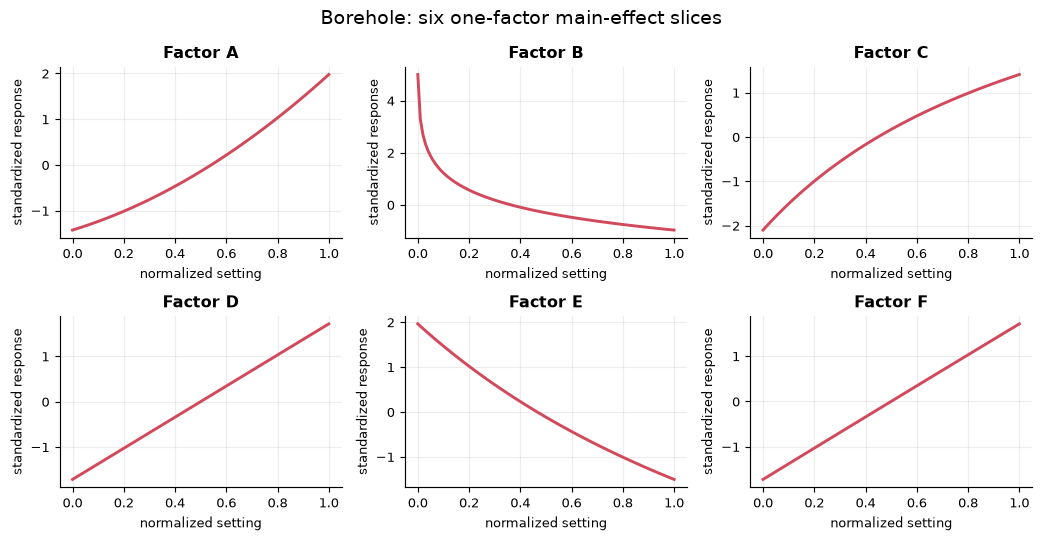

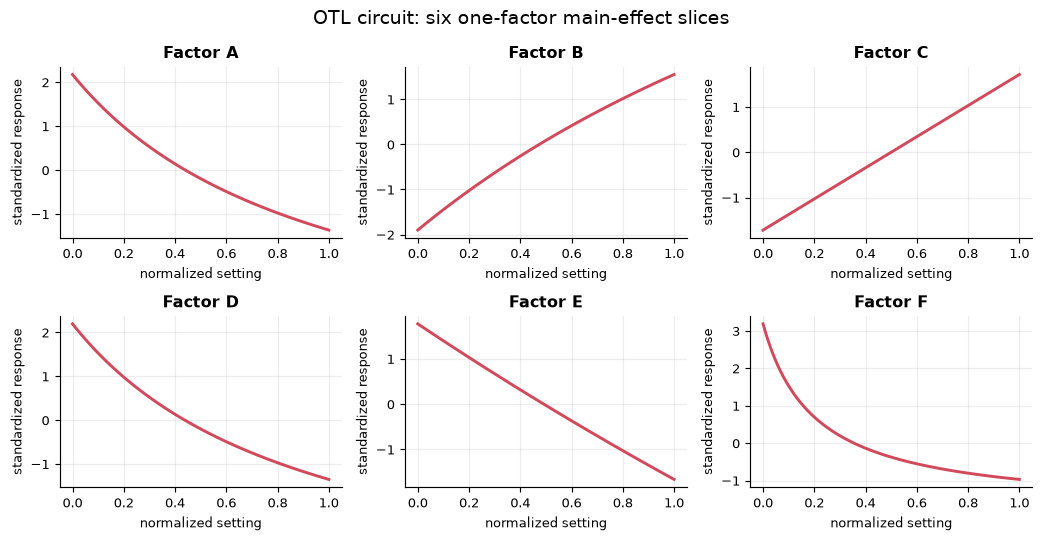

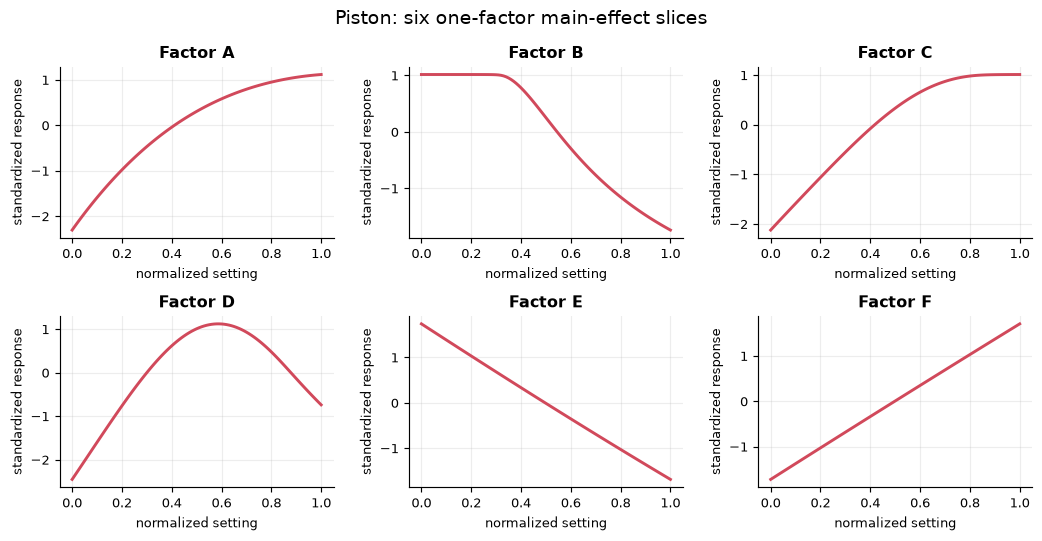

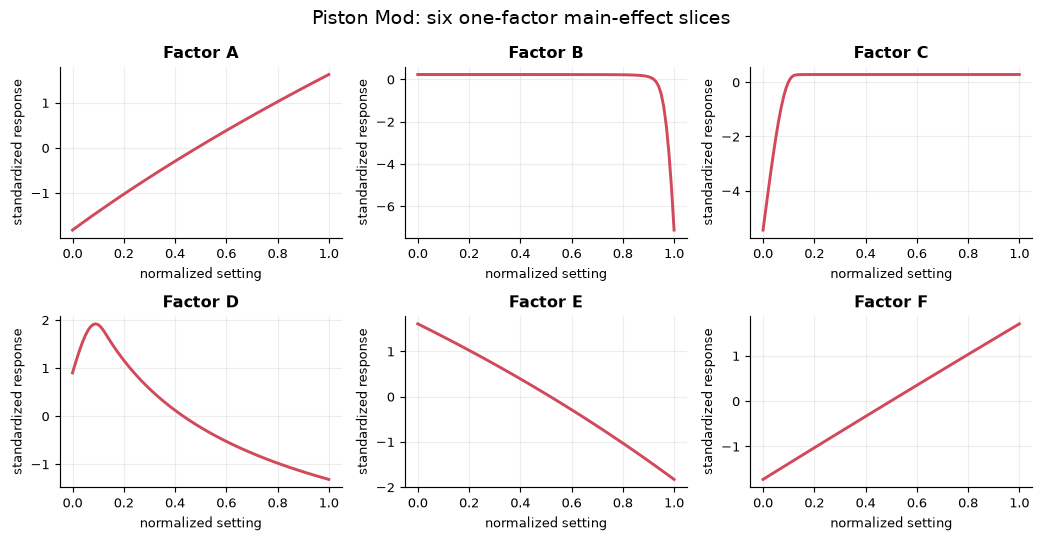

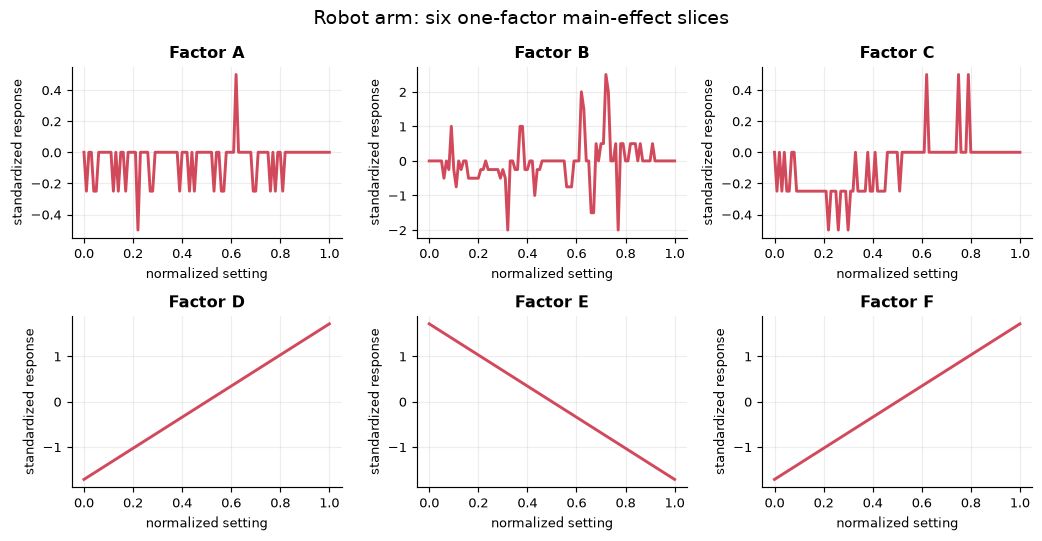

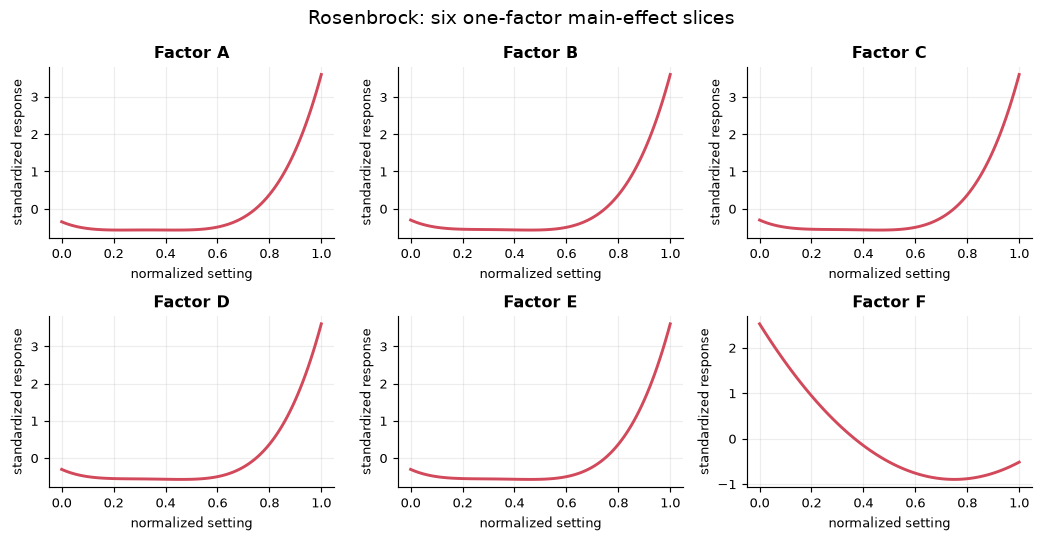

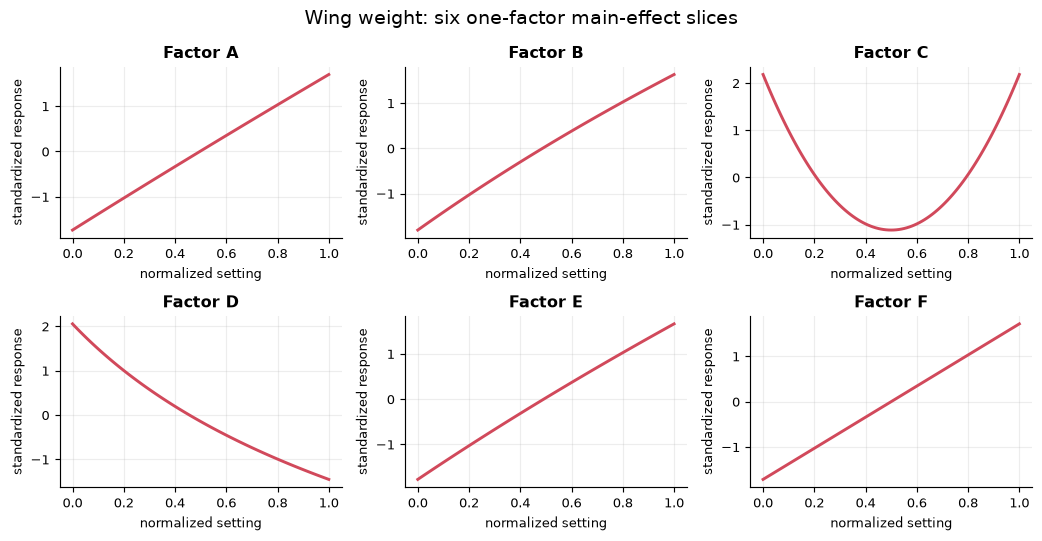

In [3]:
# Main-effect curves: E[y | x_i, other inputs at their midpoints].
grid = np.linspace(0, 1, 101)
factor_names = list("ABCDEF")
for name in FUNCTIONS:
    fig, axes = plt.subplots(2, 3, figsize=(10, 5.2), sharey=False)
    for j, ax in enumerate(axes.flat):
        X = np.full((len(grid), 6), 0.5)
        X[:, j] = grid
        y = evaluate_function(name, X)
        y = (y - y.mean()) / max(y.std(), np.finfo(float).eps)
        ax.plot(grid, y, color="#d1495b", lw=2)
        ax.set_title(f"Factor {factor_names[j]}")
        ax.set_xlabel("normalized setting")
        ax.set_ylabel("standardized response")
    fig.suptitle(f"{name}: six one-factor main-effect slices", fontsize=13)
    fig.tight_layout()
    plt.show()

### 2.1 Response normalization and noise

The paper standardizes each response with moments estimated over very
large random LHDs. The balanced profile uses one 200,000-run LHD per
function. The paper-scale profile uses 100 independent 500,000-run LHDs,
taking the average mean and maximum standard deviation as published.

Homoscedastic standard deviations are \(0, 0.05, 0.125, 0.2,\)
and \(0.5\) times the global response standard deviation.
Heteroscedastic standard deviation rises linearly from \(0.05\sigma_y\)
at the minimum response to \(0.5\sigma_y\), \(1\sigma_y\), or
\(5\sigma_y\) at the maximum.

In [4]:
def estimate_function_stats(name):
    means, stds, minima, maxima = [], [], [], []
    for r in range(CFG["normalization_repeats"]):
        X = lhs(
            6,
            samples=CFG["normalization_points"],
            seed=stable_seed("normalization", name, r),
        )
        y = evaluate_function(name, X)
        means.append(float(y.mean()))
        stds.append(float(y.std(ddof=1)))
        minima.append(float(y.min()))
        maxima.append(float(y.max()))
    return {
        "mean": float(np.mean(means)),
        "std": float(np.max(stds)),
        "min": float(np.min(minima)),
        "max": float(np.max(maxima)),
    }

t0 = time.perf_counter()
FUNCTION_STATS = {name: estimate_function_stats(name) for name in FUNCTIONS}
print(f"Normalization statistics estimated in {time.perf_counter()-t0:.1f}s")
stats_df = pd.DataFrame(FUNCTION_STATS).T
assert (stats_df["std"] > 0).all()
assert (stats_df["max"] > stats_df["min"]).all()
stats_df.round(5)

Normalization statistics estimated in 0.9s


,mean,std,min,max
Borehole,58.52346,45.85948,1.79452,3.127450e+02
OTL circuit,5.43425,1.14316,2.65108,9.410290e+00
Piston,0.59128,0.19086,0.18223,1.494520e+00
Piston Mod,0.74390,0.19881,0.20585,1.533400e+00
Robot arm,0.88873,0.45746,0.00234,2.861510e+00
Rosenbrock,637760.37911,477063.64761,58.40639,3.432926e+06
Wing weight,263.22483,28.04115,188.91233,3.634110e+02


In [5]:
NOISES = [
    {"label": "hom_0", "type": "homoscedastic", "fraction": 0.0},
    {"label": "hom_5", "type": "homoscedastic", "fraction": 0.05},
    {"label": "hom_12.5", "type": "homoscedastic", "fraction": 0.125},
    {"label": "hom_20", "type": "homoscedastic", "fraction": 0.20},
    {"label": "hom_50", "type": "homoscedastic", "fraction": 0.50},
    {"label": "het_5_50", "type": "heteroscedastic", "max_fraction": 0.50},
    {"label": "het_5_100", "type": "heteroscedastic", "max_fraction": 1.00},
    {"label": "het_5_500", "type": "heteroscedastic", "max_fraction": 5.00},
]
NOISE_MAP = {item["label"]: item for item in NOISES}

def noise_standard_deviation(name, y_raw, noise):
    st = FUNCTION_STATS[name]
    if noise["type"] == "homoscedastic":
        return np.full_like(y_raw, noise["fraction"]*st["std"], dtype=float)
    lo = 0.05*st["std"]
    hi = noise["max_fraction"]*st["std"]
    position = np.clip((y_raw - st["min"])/(st["max"] - st["min"]), 0, 1)
    return lo + (hi - lo)*position

def noisy_standardized_response(name, X_unit, noise, seed):
    y_raw = evaluate_function(name, X_unit)
    sd = noise_standard_deviation(name, y_raw, noise)
    rng = np.random.default_rng(seed)
    y_noisy = y_raw + rng.normal(0, sd)
    st = FUNCTION_STATS[name]
    return (y_noisy - st["mean"])/st["std"], y_raw, sd

# Empirical tests of the noise construction.
X_noise_check = lhs(6, samples=20_000, seed=stable_seed("noise-check"))
y_piston = evaluate_function("Piston", X_noise_check)
hom_empirical = []
for item in NOISES[:5]:
    sd = noise_standard_deviation("Piston", y_piston, item)
    hom_empirical.append(sd.mean())
assert np.all(np.diff(hom_empirical) >= 0)
for item in NOISES[5:]:
    sd = noise_standard_deviation("Piston", y_piston, item)
    assert np.corrcoef(y_piston, sd)[0, 1] > 0.99
print("Noise checks passed.")

Noise checks passed.


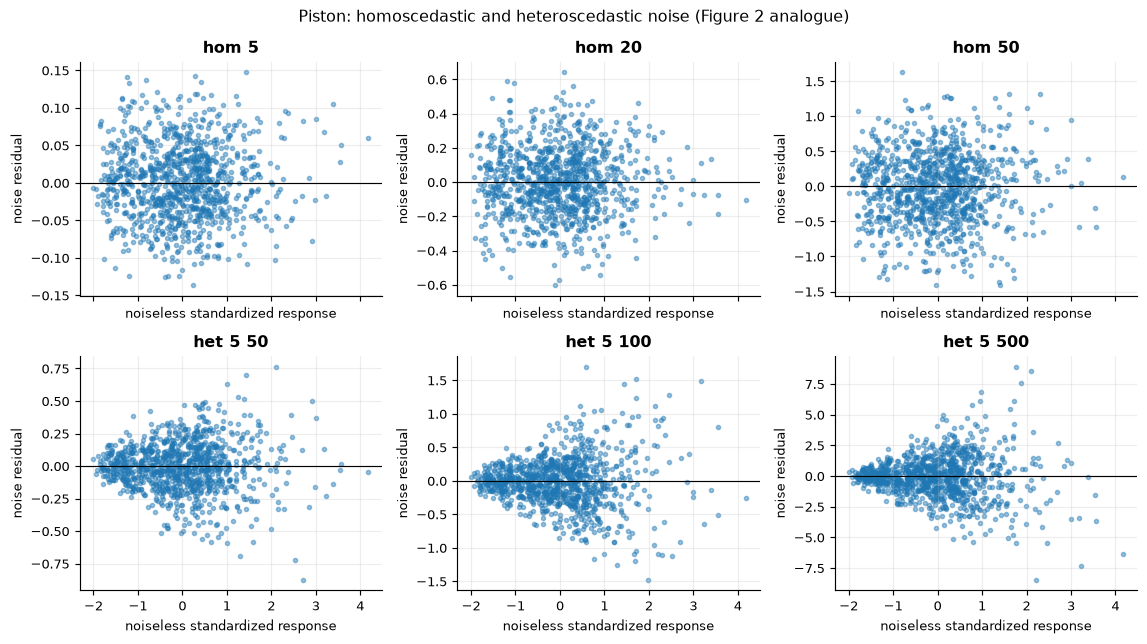

In [6]:
# Figure 2 analogue: residuals under representative noise magnitudes.
X_noise = lhs(6, samples=1_000, seed=stable_seed("figure-2"))
y_raw = evaluate_function("Piston", X_noise)
order = np.argsort(y_raw)
panels = ["hom_5", "hom_20", "hom_50", "het_5_50", "het_5_100", "het_5_500"]
fig, axes = plt.subplots(2, 3, figsize=(11, 6.2), sharex=True)
for ax, label in zip(axes.flat, panels):
    item = NOISE_MAP[label]
    y_std, _, _ = noisy_standardized_response(
        "Piston", X_noise, item, stable_seed("figure-2", label)
    )
    deterministic = (y_raw - FUNCTION_STATS["Piston"]["mean"]) / FUNCTION_STATS["Piston"]["std"]
    residual = y_std - deterministic
    ax.scatter(deterministic[order], residual[order], s=8, alpha=0.45)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(label.replace("_", " "))
    ax.set_xlabel("noiseless standardized response")
    ax.set_ylabel("noise residual")
fig.suptitle("Piston: homoscedastic and heteroscedastic noise (Figure 2 analogue)")
fig.tight_layout()
plt.show()

## 3. Reconstruct the design

All designs are represented in \([0,1]^6\). A dagger (`†`) in a name
marks a material approximation.

* `CCD52†` uses a 32-run resolution-VI half fraction (at least the
  requested resolution V), 12 rotatable axial points, and eight centers.
* `BBD64†` is the design returned by `pydoe.bbdesign(6, center=4)`.
  Its extra 12 runs make it a sensitivity design, not part of the
  primary equal-budget ranking.
* Optimal designs use pyDOE over a deterministic subset of the \(6^6\)
  full-factorial candidate set. Different candidate orderings and search
  methods stand in for the proprietary Minitab/JMP implementations.
* `MAXPRO_dis†` rank-projects a continuous pyDOE MaxPro design onto six
  balanced levels. It is **not** the generalized discrete MaxPro
  criterion used by the paper.

In [7]:
def unitize_coded(X, low=None, high=None):
    X = np.asarray(X, dtype=float)
    low = X.min(axis=0) if low is None else np.broadcast_to(low, X.shape[1])
    high = X.max(axis=0) if high is None else np.broadcast_to(high, X.shape[1])
    return (X - low)/(high - low)

def ccd52():
    factorial = fracfact("a b c d e abcde")  # 32-run resolution VI
    axial, _ = star(6, alpha="faced")
    alpha = factorial.shape[0]**0.25
    axial = axial*alpha
    centers = np.zeros((8, 6))
    coded = np.vstack([factorial, axial, centers])
    return (coded + alpha)/(2*alpha)

def candidate_pool(seed, n_pool=None):
    n_pool = n_pool or CFG["optimal_candidate_pool"]
    grid = fullfact([6]*6)/5
    corner_mask = np.all((grid == 0) | (grid == 1), axis=1)
    corners = grid[corner_mask]
    interior = grid[~corner_mask]
    rng = np.random.default_rng(seed)
    n_extra = max(n_pool - len(corners), 0)
    extra = interior[rng.choice(len(interior), n_extra, replace=False)]
    pool = np.vstack([corners, extra])
    rng.shuffle(pool)
    return pool

def pydoe_optimal(seed, criterion, n_points=52, degree=2, method="sequential"):
    pool = candidate_pool(seed)
    design, info = optimal_design(
        pool,
        n_points=n_points,
        degree=degree,
        criterion=criterion,
        method=method,
        alpha=1e-6,
        max_iter=CFG["optimal_exchange_iterations"],
    )
    return design, info

def balanced_six_level_projection(X):
    X = np.asarray(X)
    n = len(X)
    result = np.empty_like(X)
    for j in range(X.shape[1]):
        ranks = np.empty(n, dtype=int)
        ranks[np.argsort(X[:, j], kind="mergesort")] = np.arange(n)
        bins = np.minimum((ranks*6)//n, 5)
        result[:, j] = bins/5
    return result

def repeat_fraction(base_generator, unique_runs, duplicate_runs, seed):
    base = base_generator(unique_runs, seed)
    rng = np.random.default_rng(seed)
    chosen = rng.choice(unique_runs, duplicate_runs, replace=False)
    return np.vstack([base, base[chosen]])

t0 = time.perf_counter()
FFD, ffd_info = pydoe_optimal(
    stable_seed("FFD"), "D", method="sequential"
)
D_OPT, d_info = pydoe_optimal(
    stable_seed("D-opt"), "D", method="simple_exchange"
)
I_OPT, i_info = pydoe_optimal(
    stable_seed("I-opt"), "I", method="simple_exchange"
)
D_BASE26, _ = pydoe_optimal(
    stable_seed("D-repl"), "D", n_points=26, degree=1, method="sequential"
)
I_BASE26, _ = pydoe_optimal(
    stable_seed("I-repl"), "I", n_points=26, degree=1, method="sequential"
)

def discrete_maxpro(n, seed):
    return balanced_six_level_projection(
        maxpro_design(
            n, 6, iterations=CFG["maxpro_iterations"], seed=seed
        )
    )

DESIGNS = {
    "CCD52†": ccd52(),
    "BBD64†": (bbdesign(6, center=4) + 1)/2,
    "FFD†": FFD,
    "D_opt†": D_OPT,
    "I_opt†": I_OPT,
    "LHD_rand": lhs(6, samples=52, seed=stable_seed("LHD")),
    "MAXPRO": maxpro_design(
        52, 6, iterations=CFG["maxpro_iterations"], seed=stable_seed("MAXPRO")
    ),
    "MAXPRO_dis†": discrete_maxpro(52, stable_seed("MAXPRO-dis")),
    "D_opt_50%repl†": np.repeat(D_BASE26, 2, axis=0),
    "I_opt_50%repl†": np.repeat(I_BASE26, 2, axis=0),
    "MAXPRO_dis_50%repl†": np.repeat(
        discrete_maxpro(26, stable_seed("MAXPRO-dis-50")), 2, axis=0
    ),
    "MAXPRO_dis_25%repl†": repeat_fraction(
        discrete_maxpro, 39, 13, stable_seed("MAXPRO-dis-25")
    ),
}
print(f"Designs generated in {time.perf_counter()-t0:.1f}s")

REPLICATED_DESIGNS = {
    "D_opt_50%repl†", "I_opt_50%repl†",
    "MAXPRO_dis_50%repl†", "MAXPRO_dis_25%repl†"
}
PRIMARY_DESIGNS = [name for name in DESIGNS if name != "BBD64†"]

def design_diagnostics(name, X):
    unique = np.unique(np.round(X, 12), axis=0)
    return {
        "design": name,
        "runs": len(X),
        "unique_runs": len(unique),
        "replication_pct": 100*(1 - len(unique)/len(X)),
        "min_levels": min(len(np.unique(np.round(X[:, j], 12))) for j in range(6)),
        "max_levels": max(len(np.unique(np.round(X[:, j], 12))) for j in range(6)),
        "min_distance_unique": pdist(unique).min() if len(unique) > 1 else np.nan,
        "primary_52_run": name in PRIMARY_DESIGNS,
        "approximation": "†" in name,
    }

diagnostics = pd.DataFrame(
    [design_diagnostics(name, X) for name, X in DESIGNS.items()]
).set_index("design")
for name, X in DESIGNS.items():
    assert X.shape[1] == 6
    assert np.isfinite(X).all()
    assert np.all((X >= -1e-12) & (X <= 1 + 1e-12))
    assert len(X) == (64 if name == "BBD64†" else 52)
assert diagnostics.loc["CCD52†", "unique_runs"] == 45  # 8 centers -> one unique center
assert diagnostics.loc["MAXPRO_dis†", "max_levels"] == 6
diagnostics.round(4)

Designs generated in 20.6s


,runs,unique_runs,replication_pct,min_levels,max_levels,min_distance_unique,primary_52_run,approximation
design,,,,,,,,
CCD52†,52,45,13.4615,5,5,0.5000,True,True
BBD64†,64,61,4.6875,3,3,0.7071,False,True
FFD†,52,52,0.0000,4,6,0.5657,True,True
D_opt†,52,52,0.0000,4,6,0.4472,True,True
I_opt†,52,52,0.0000,6,6,0.5657,True,True
LHD_rand,52,52,0.0000,52,52,0.2430,True,False
MAXPRO,52,52,0.0000,52,52,0.3936,True,False
MAXPRO_dis†,52,52,0.0000,6,6,0.4472,True,True
D_opt_50%repl†,52,26,50.0000,2,2,1.0000,True,True


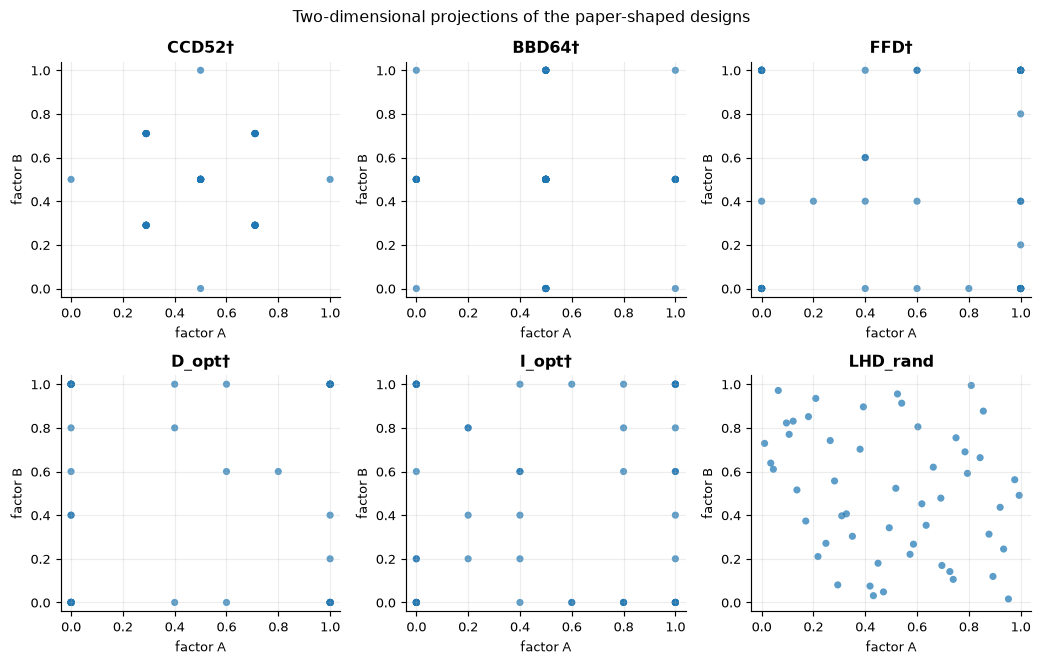

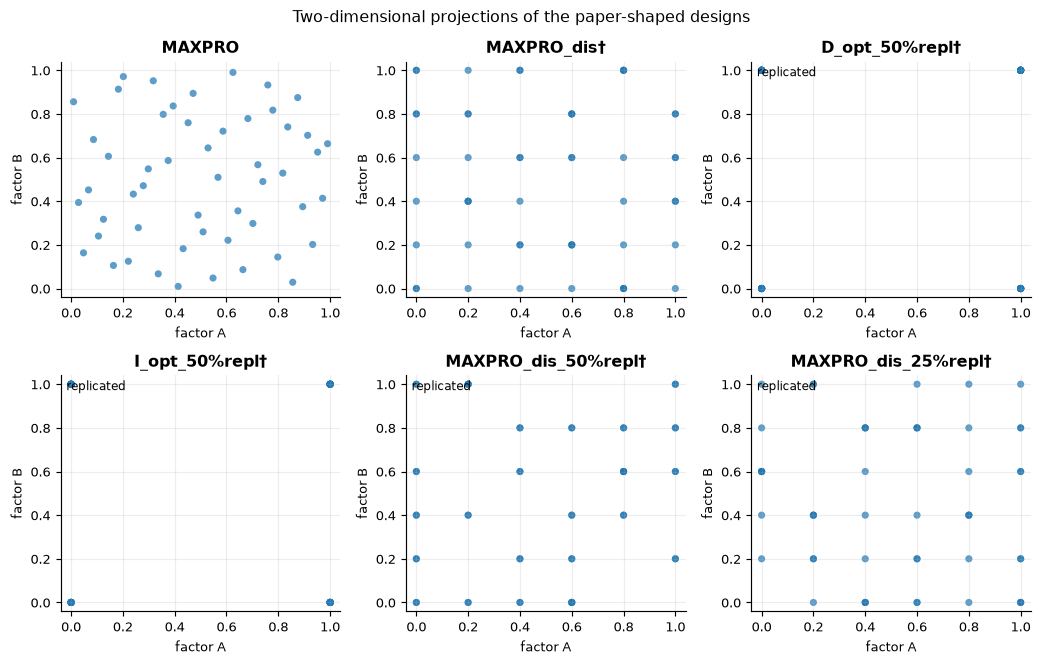

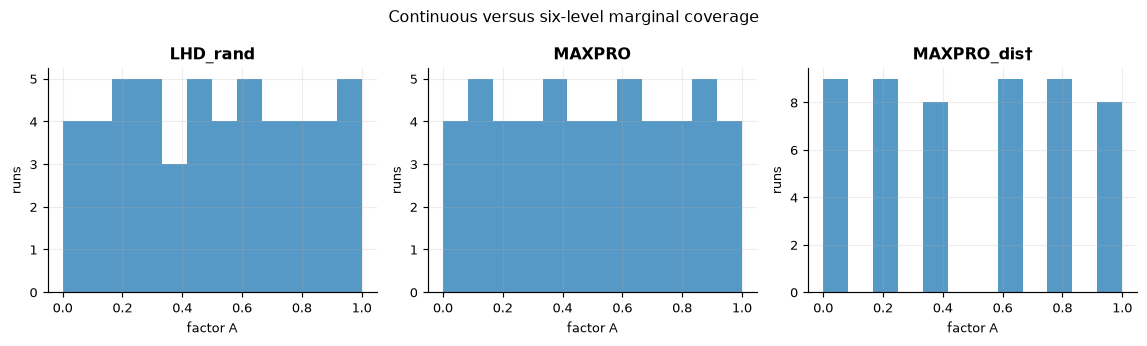

In [8]:
# Projection and marginal-level diagnostics.
groups = [
    ["CCD52†", "BBD64†", "FFD†", "D_opt†", "I_opt†", "LHD_rand"],
    ["MAXPRO", "MAXPRO_dis†", "D_opt_50%repl†", "I_opt_50%repl†",
     "MAXPRO_dis_50%repl†", "MAXPRO_dis_25%repl†"],
]
for names in groups:
    fig, axes = plt.subplots(2, 3, figsize=(10, 6.4))
    for ax, name in zip(axes.flat, names):
        X = DESIGNS[name]
        ax.scatter(X[:, 0], X[:, 1], s=24, alpha=0.72, edgecolor="none")
        ax.set(xlim=(-0.04, 1.04), ylim=(-0.04, 1.04),
               xlabel="factor A", ylabel="factor B", title=name)
        if name in REPLICATED_DESIGNS:
            ax.text(0.02, 0.98, "replicated", transform=ax.transAxes,
                    va="top", fontsize=8)
    fig.suptitle("Two-dimensional projections of the paper-shaped designs")
    fig.tight_layout()
    plt.show()

fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
for ax, name in zip(axes, ["LHD_rand", "MAXPRO", "MAXPRO_dis†"]):
    X = DESIGNS[name]
    ax.hist(X[:, 0], bins=np.linspace(0, 1, 13), alpha=0.75)
    ax.set(title=name, xlabel="factor A", ylabel="runs")
fig.suptitle("Continuous versus six-level marginal coverage")
fig.tight_layout()
plt.show()

## 4. Understand the design

Six model families are available in scikit-learn. H2O AutoML is skipped.
The quadratic Ridge model is a stable approximation to the paper's
stepwise second-order LM. The deep MLP lacks dropout and Maxout and is
consequently labeled as an approximation.

To preserve the all-function/all-noise/all-design simulation matrix,
one compact CV search per function/noise/model is run on representative
LHD training data. The selected configuration is then reused across
designs and repetitions. GP kernel hyperparameters are optimized during
this search and frozen for the comparison fits.

In [9]:
MODEL_NAMES = ["LM", "GP", "SVM", "RF", "ANN_sh", "ANN_dp†"]

def compact_cv(seed):
    return KFold(
        n_splits=CFG["cv_folds"], shuffle=True, random_state=seed
    )

def tune_model(model_name, X, y, seed):
    cv = compact_cv(seed)
    if model_name == "GP":
        kernels = [
            ConstantKernel(1.0, (1e-2, 1e2))*RBF(np.ones(6), (1e-2, 1e2)),
            ConstantKernel(1.0, (1e-2, 1e2))*Matern(np.ones(6), (1e-2, 1e2), nu=0.5),
            ConstantKernel(1.0, (1e-2, 1e2))*Matern(np.ones(6), (1e-2, 1e2), nu=1.5),
            ConstantKernel(1.0, (1e-2, 1e2))*Matern(np.ones(6), (1e-2, 1e2), nu=2.5),
        ]
        search = GridSearchCV(
            GaussianProcessRegressor(
                alpha=1e-8, normalize_y=True, random_state=seed
            ),
            {"kernel": kernels},
            scoring="neg_root_mean_squared_error",
            cv=cv,
            n_jobs=1,
        ).fit(X, y)
        return {
            "kernel": copy.deepcopy(search.best_estimator_.kernel_),
            "description": str(search.best_estimator_.kernel_),
        }

    if model_name == "SVM":
        pipe = Pipeline([("scale", StandardScaler()), ("model", SVR())])
        candidates = [
            {"model__kernel": ["linear"], "model__C": [10.0], "model__epsilon": [0.05]},
            {"model__kernel": ["rbf"], "model__C": [10.0], "model__gamma": ["scale"], "model__epsilon": [0.05]},
            {"model__kernel": ["rbf"], "model__C": [100.0], "model__gamma": ["scale"], "model__epsilon": [0.05]},
            {"model__kernel": ["poly"], "model__degree": [2], "model__C": [10.0], "model__epsilon": [0.05]},
        ]
        search = GridSearchCV(
            pipe, candidates, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=1
        ).fit(X, y)
        return {
            "params": search.best_params_,
            "description": str(search.best_params_),
        }

    if model_name == "RF":
        candidates = [
            {"max_features": [1.0], "min_samples_leaf": [1]},
            {"max_features": ["sqrt"], "min_samples_leaf": [1]},
            {"max_features": [0.5], "min_samples_leaf": [2]},
        ]
        search = GridSearchCV(
            RandomForestRegressor(
                n_estimators=CFG["rf_trees"], n_jobs=-1, random_state=seed
            ),
            candidates,
            scoring="neg_root_mean_squared_error",
            cv=cv,
            n_jobs=1,
        ).fit(X, y)
        return {
            "params": search.best_params_,
            "description": str(search.best_params_),
        }

    if model_name in {"ANN_sh", "ANN_dp†"}:
        pipe = Pipeline(
            [
                ("scale", StandardScaler()),
                ("model", MLPRegressor(
                    solver="lbfgs", max_iter=500, random_state=seed
                )),
            ]
        )
        if model_name == "ANN_sh":
            candidates = [
                {"model__hidden_layer_sizes": [(3,)], "model__activation": ["tanh"], "model__alpha": [0.0]},
                {"model__hidden_layer_sizes": [(6,)], "model__activation": ["tanh"], "model__alpha": [0.01]},
                {"model__hidden_layer_sizes": [(9,)], "model__activation": ["relu"], "model__alpha": [0.1]},
                {"model__hidden_layer_sizes": [(12,)], "model__activation": ["tanh"], "model__alpha": [0.5]},
            ]
        else:
            candidates = [
                {"model__hidden_layer_sizes": [(6, 6)], "model__activation": ["tanh"], "model__alpha": [0.01]},
                {"model__hidden_layer_sizes": [(12, 12)], "model__activation": ["relu"], "model__alpha": [0.1]},
                {"model__hidden_layer_sizes": [(6, 6, 6)], "model__activation": ["tanh"], "model__alpha": [0.1]},
                {"model__hidden_layer_sizes": [(12, 12, 12)], "model__activation": ["relu"], "model__alpha": [0.5]},
            ]
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            search = GridSearchCV(
                pipe, candidates, scoring="neg_root_mean_squared_error",
                cv=cv, n_jobs=1, error_score="raise"
            ).fit(X, y)
        return {
            "params": search.best_params_,
            "description": str(search.best_params_),
        }
    raise ValueError(model_name)

def make_model(model_name, tuned, seed):
    if model_name == "LM":
        return Pipeline(
            [
                ("quadratic", PolynomialFeatures(degree=2, include_bias=False)),
                ("scale", StandardScaler()),
                ("ridge", RidgeCV(alphas=np.logspace(-6, 2, 9))),
            ]
        )
    if model_name == "GP":
        return GaussianProcessRegressor(
            kernel=copy.deepcopy(tuned["kernel"]),
            alpha=1e-8,
            optimizer=None,
            normalize_y=True,
            random_state=seed,
        )
    if model_name == "SVM":
        model = Pipeline([("scale", StandardScaler()), ("model", SVR())])
        return model.set_params(**tuned["params"])
    if model_name == "RF":
        return RandomForestRegressor(
            n_estimators=CFG["rf_trees"],
            n_jobs=-1,
            random_state=seed,
            **tuned["params"],
        )
    if model_name in {"ANN_sh", "ANN_dp†"}:
        model = Pipeline(
            [
                ("scale", StandardScaler()),
                ("model", MLPRegressor(
                    solver="lbfgs", max_iter=500, random_state=seed
                )),
            ]
        )
        return model.set_params(**tuned["params"])
    raise ValueError(model_name)

# Test all model constructors on a small deterministic dataset.
X_smoke = lhs(6, samples=52, seed=stable_seed("model-smoke"))
y_smoke = (evaluate_function("Piston", X_smoke) - FUNCTION_STATS["Piston"]["mean"]) / FUNCTION_STATS["Piston"]["std"]
smoke_tuned = {
    "GP": {"kernel": ConstantKernel(1.0)*Matern(np.ones(6), nu=2.5)},
    "SVM": {"params": {"model__kernel": "rbf", "model__C": 10.0, "model__gamma": "scale", "model__epsilon": 0.05}},
    "RF": {"params": {"max_features": "sqrt", "min_samples_leaf": 1}},
    "ANN_sh": {"params": {"model__hidden_layer_sizes": (6,), "model__activation": "tanh", "model__alpha": 0.01}},
    "ANN_dp†": {"params": {"model__hidden_layer_sizes": (6, 6), "model__activation": "tanh", "model__alpha": 0.1}},
}
for model_name in MODEL_NAMES:
    tuned = smoke_tuned.get(model_name)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        pred = make_model(model_name, tuned, stable_seed("smoke", model_name)).fit(X_smoke, y_smoke).predict(X_smoke[:3])
    assert np.isfinite(pred).all()
print("All model constructors passed a smoke test.")

All model constructors passed a smoke test.


In [10]:
# Tune once for every function/noise/model combination on an LHD.
TUNED = {}
tuning_rows = []
t0 = time.perf_counter()
for f_idx, function_name in enumerate(FUNCTIONS):
    X_ref = lhs(6, samples=52, seed=stable_seed("tune-X", function_name))
    for noise in NOISES:
        y_ref, _, _ = noisy_standardized_response(
            function_name,
            X_ref,
            noise,
            stable_seed("tune-y", function_name, noise["label"]),
        )
        for model_name in MODEL_NAMES:
            if model_name == "LM":
                continue
            seed = stable_seed("tune-model", function_name, noise["label"], model_name)
            start = time.perf_counter()
            tuned = tune_model(model_name, X_ref, y_ref, seed)
            TUNED[(function_name, noise["label"], model_name)] = tuned
            tuning_rows.append(
                {
                    "function": function_name,
                    "noise_level": noise["label"],
                    "model": model_name,
                    "best_configuration": tuned["description"],
                    "seconds": time.perf_counter() - start,
                }
            )
    print(f"Tuned {function_name} ({f_idx+1}/{len(FUNCTIONS)})")
tuning_df = pd.DataFrame(tuning_rows)
print(f"Compact tuning completed in {(time.perf_counter()-t0)/60:.1f} min")
tuning_df.groupby("model")["seconds"].agg(["count", "mean", "sum"]).round(3)

Tuned Borehole (1/7)


Tuned OTL circuit (2/7)


Tuned Piston (3/7)


Tuned Piston Mod (4/7)


Tuned Robot arm (5/7)


Tuned Rosenbrock (6/7)


Tuned Wing weight (7/7)
Compact tuning completed in 8.5 min


,count,mean,sum
model,,,
ANN_dp†,56,2.390,133.837
ANN_sh,56,1.249,69.957
GP,56,0.371,20.795
RF,56,5.038,282.123
SVM,56,0.069,3.848


## 5. Reproduce the article analysis

Every model is trained on the noisy response observed at an experimental
design and evaluated against the noiseless standardized response on a
fixed 1,000-run LHD for that test function. RMSE is the comparison
metric. LM is intentionally omitted from replicated designs, matching
the paper's treatment.

In [11]:
TEST_SETS = {}
for name in FUNCTIONS:
    X_test = lhs(
        6, samples=CFG["test_points"], seed=stable_seed("test", name)
    )
    st = FUNCTION_STATS[name]
    y_test = (evaluate_function(name, X_test) - st["mean"])/st["std"]
    TEST_SETS[name] = (X_test, y_test)

rows = []
t0 = time.perf_counter()
for f_idx, function_name in enumerate(FUNCTIONS):
    X_test, y_test = TEST_SETS[function_name]
    for noise in NOISES:
        for design_name, X_train in DESIGNS.items():
            for repetition in range(CFG["simulation_repeats"]):
                y_train, _, _ = noisy_standardized_response(
                    function_name,
                    X_train,
                    noise,
                    stable_seed(
                        "response", function_name, noise["label"],
                        design_name, repetition
                    ),
                )
                for model_name in MODEL_NAMES:
                    record = {
                        "function": function_name,
                        "noise_type": noise["type"],
                        "noise_level": noise["label"],
                        "design": design_name,
                        "model": model_name,
                        "repetition": repetition,
                        "rmse": np.nan,
                        "fit_seconds": 0.0,
                        "status": "ok",
                        "selected_hyperparameters": "",
                    }
                    if model_name == "LM" and design_name in REPLICATED_DESIGNS:
                        record["status"] = "intentional_skip_replicated_LM"
                        rows.append(record)
                        continue
                    tuned = None if model_name == "LM" else TUNED[
                        (function_name, noise["label"], model_name)
                    ]
                    seed = stable_seed(
                        "fit", function_name, noise["label"],
                        design_name, repetition, model_name
                    )
                    model = make_model(model_name, tuned, seed)
                    start = time.perf_counter()
                    try:
                        with warnings.catch_warnings():
                            warnings.simplefilter("ignore")
                            model.fit(X_train, y_train)
                        pred = model.predict(X_test)
                        record["rmse"] = float(
                            mean_squared_error(y_test, pred)**0.5
                        )
                        if not np.isfinite(record["rmse"]):
                            raise FloatingPointError("non-finite RMSE")
                        if model_name == "LM":
                            ridge = model.named_steps["ridge"]
                            record["selected_hyperparameters"] = f"alpha={ridge.alpha_:.5g}"
                        else:
                            record["selected_hyperparameters"] = tuned["description"]
                    except (ValueError, FloatingPointError, np.linalg.LinAlgError) as exc:
                        record["status"] = f"failed:{type(exc).__name__}:{exc}"
                    record["fit_seconds"] = time.perf_counter() - start
                    rows.append(record)
    elapsed = (time.perf_counter() - t0)/60
    print(
        f"Completed {function_name} ({f_idx+1}/{len(FUNCTIONS)}) "
        f"after {elapsed:.1f} min"
    )

results = pd.DataFrame(rows)
expected = (
    len(FUNCTIONS)*len(NOISES)*len(DESIGNS)
    * CFG["simulation_repeats"]*len(MODEL_NAMES)
)
assert len(results) == expected
ok_results = results[results["status"] == "ok"].copy()
unexpected = results[
    ~results["status"].isin(["ok", "intentional_skip_replicated_LM"])
]
assert unexpected.empty, unexpected["status"].value_counts()
assert np.isfinite(ok_results["rmse"]).all()
print(
    f"Simulation completed in {(time.perf_counter()-t0)/60:.1f} min: "
    f"{len(ok_results):,} fitted models and "
    f"{(results['status'] != 'ok').sum():,} intentional omissions."
)
ok_results.head()

Completed Borehole (1/7) after 6.6 min


Completed OTL circuit (2/7) after 12.4 min


Completed Piston (3/7) after 19.6 min


Completed Piston Mod (4/7) after 26.9 min


Completed Robot arm (5/7) after 33.5 min


Completed Rosenbrock (6/7) after 40.0 min


Completed Wing weight (7/7) after 46.3 min


Simulation completed in 46.3 min: 19,040 fitted models and 1,120 intentional omissions.


,function,noise_type,noise_level,design,model,repetition,rmse,fit_seconds,status,selected_hyperparameters
0,Borehole,homoscedastic,hom_0,CCD52†,LM,0,0.078899,0.040690,ok,alpha=0.1
1,Borehole,homoscedastic,hom_0,CCD52†,GP,0,0.079686,0.045777,ok,"5.68**2 * RBF(length_scale=[1.15, 100, 93.3, 3..."
2,Borehole,homoscedastic,hom_0,CCD52†,SVM,0,0.389438,0.010440,ok,"{'model__C': 10.0, 'model__epsilon': 0.05, 'mo..."
3,Borehole,homoscedastic,hom_0,CCD52†,RF,0,0.589336,1.502591,ok,"{'max_features': 0.5, 'min_samples_leaf': 2}"
4,Borehole,homoscedastic,hom_0,CCD52†,ANN_sh,0,0.203142,0.085769,ok,"{'model__activation': 'tanh', 'model__alpha': ..."


In [12]:
# Simulation timing and RMSE sanity summaries.
timing_summary = (
    ok_results.groupby("model")
    .agg(fits=("rmse", "size"), median_rmse=("rmse", "median"),
         total_minutes=("fit_seconds", lambda x: x.sum()/60))
    .sort_values("median_rmse")
)
assert (timing_summary["fits"] > 0).all()
timing_summary.round(3)

,fits,median_rmse,total_minutes
model,,,
GP,3360,0.433,0.209
LM,2240,0.487,0.220
ANN_sh,3360,0.512,4.327
ANN_dp†,3360,0.514,11.615
SVM,3360,0.577,0.520
RF,3360,0.673,29.282


### 5.1 Raw-error reproduction of Figure 3

Each colored point is one RMSE from a simulation repetition. Large
black stars are model means. `BBD64†` is shown but remains outside the
primary equal-budget rank.

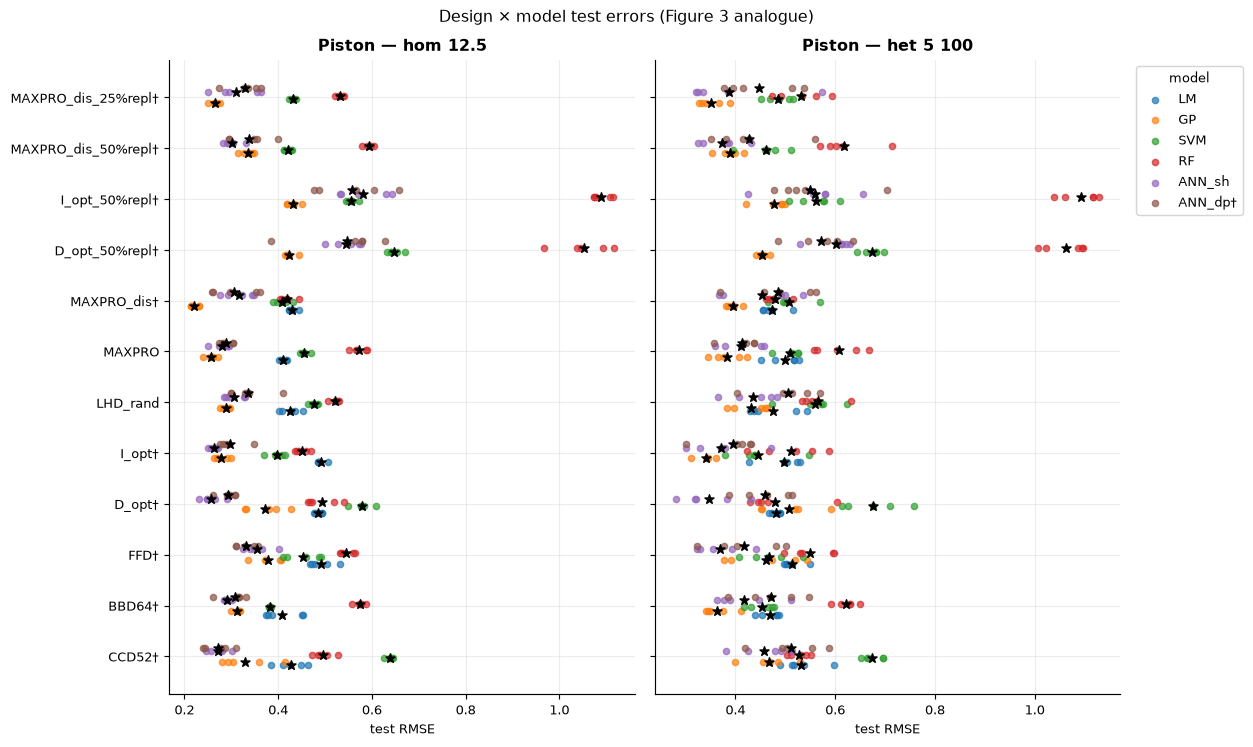

In [13]:
model_colors = dict(zip(MODEL_NAMES, plt.cm.tab10.colors[:len(MODEL_NAMES)]))
design_order = list(DESIGNS)

fig, axes = plt.subplots(1, 2, figsize=(12, 7.2), sharey=True)
for ax, noise_label in zip(axes, ["hom_12.5", "het_5_100"]):
    subset = ok_results[
        (ok_results["function"] == "Piston")
        & (ok_results["noise_level"] == noise_label)
    ]
    for d_idx, design_name in enumerate(design_order):
        for m_idx, model_name in enumerate(MODEL_NAMES):
            vals = subset[
                (subset["design"] == design_name)
                & (subset["model"] == model_name)
            ]["rmse"].to_numpy()
            if len(vals) == 0:
                continue
            y = d_idx + (m_idx - (len(MODEL_NAMES)-1)/2)*0.07
            ax.scatter(
                vals, np.full(len(vals), y), s=18,
                color=model_colors[model_name], alpha=0.7,
                label=model_name if d_idx == 0 else None,
            )
            ax.scatter(
                vals.mean(), y, marker="*", s=42, color="black", zorder=4
            )
    ax.set(
        title=f"Piston — {noise_label.replace('_', ' ')}",
        xlabel="test RMSE",
        yticks=np.arange(len(design_order)),
        yticklabels=design_order,
    )
    ax.invert_yaxis()
axes[1].legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Design × model test errors (Figure 3 analogue)")
fig.tight_layout()
plt.show()

### 5.2 Two-stage nonparametric ranking

For each directional comparison, the statistic is
\(\bar{\mathrm{RMSE}}_i-\bar{\mathrm{RMSE}}_j\).
Design samples are permuted independently; model samples remain paired
by repetition. P-values across dependent variables are combined with
Fisher's function. A rank score combines significant losses and wins;
lower is better. The procedure is then applied to the function-level
ranks to obtain final ranks for every noise setting.

In [14]:
def mean_difference(a, b, axis=0):
    return np.mean(a, axis=axis) - np.mean(b, axis=axis)

def directional_pvalue(a, b, paired, seed):
    a, b = np.asarray(a), np.asarray(b)
    if len(a) == 0 or len(b) == 0:
        return np.nan
    result = permutation_test(
        (a, b),
        mean_difference,
        permutation_type="samples" if paired else "independent",
        vectorized=True,
        n_resamples=CFG["permutations"],
        alternative="greater",
        rng=np.random.default_rng(seed),
    )
    return float(result.pvalue)

def significance_rank(items, p_matrix, mean_error):
    C = len(items)
    S = np.nan_to_num(p_matrix, nan=1.0) <= 0.025
    np.fill_diagonal(S, False)
    losses = S.sum(axis=1)
    wins = S.sum(axis=0)
    score = (1 + losses + (C - wins))/2
    # Mean error breaks significance ties without overriding them.
    ordering = pd.DataFrame(
        {"item": items, "score": score, "mean_error": mean_error}
    ).sort_values(["score", "mean_error", "item"])
    ordering["rank"] = np.arange(1, C + 1)
    ranks = ordering.set_index("item")["rank"].reindex(items).to_numpy()
    return ranks.astype(int)

def first_stage_rank(frame, items, variables, item_col, paired, seed_tag):
    C = len(items)
    pmat = np.ones((C, C))
    means = np.zeros(C)
    means[:] = [
        frame.loc[frame[item_col] == item, "rmse"].mean() for item in items
    ]
    for i, j in itertools.permutations(range(C), 2):
        pvals = []
        for variable in variables:
            a = frame[
                (frame[item_col] == items[i])
                & (frame["model" if item_col == "design" else "design"] == variable)
            ].sort_values("repetition")["rmse"].to_numpy()
            b = frame[
                (frame[item_col] == items[j])
                & (frame["model" if item_col == "design" else "design"] == variable)
            ].sort_values("repetition")["rmse"].to_numpy()
            if paired:
                n = min(len(a), len(b))
                a, b = a[:n], b[:n]
            p = directional_pvalue(
                a, b, paired,
                stable_seed(seed_tag, items[i], items[j], variable)
            )
            if np.isfinite(p):
                pvals.append(max(p, np.finfo(float).tiny))
        if pvals:
            pmat[i, j] = combine_pvalues(pvals, method="fisher").pvalue
    return significance_rank(items, pmat, means)

def second_stage_rank(rank_frame, items, noise_label, seed_tag):
    C = len(items)
    pmat = np.ones((C, C))
    means = np.array(
        [rank_frame.loc[rank_frame["item"] == item, "rank"].mean() for item in items]
    )
    for i, j in itertools.permutations(range(C), 2):
        a = rank_frame.loc[rank_frame["item"] == items[i], "rank"].to_numpy()
        b = rank_frame.loc[rank_frame["item"] == items[j], "rank"].to_numpy()
        pmat[i, j] = directional_pvalue(
            a, b, False,
            stable_seed(seed_tag, noise_label, items[i], items[j])
        )
    return significance_rank(items, pmat, means)

design_rank_rows = []
model_rank_rows = []
t0 = time.perf_counter()
for function_name in FUNCTIONS:
    for noise in NOISES:
        frame = ok_results[
            (ok_results["function"] == function_name)
            & (ok_results["noise_level"] == noise["label"])
            & (ok_results["design"].isin(PRIMARY_DESIGNS))
        ]
        d_ranks = first_stage_rank(
            frame, PRIMARY_DESIGNS, MODEL_NAMES,
            item_col="design", paired=False,
            seed_tag=("rank-design", function_name, noise["label"]),
        )
        for item, rank in zip(PRIMARY_DESIGNS, d_ranks):
            design_rank_rows.append(
                {"function": function_name, "noise_level": noise["label"],
                 "item": item, "rank": rank}
            )
        m_ranks = first_stage_rank(
            frame, MODEL_NAMES, PRIMARY_DESIGNS,
            item_col="model", paired=True,
            seed_tag=("rank-model", function_name, noise["label"]),
        )
        for item, rank in zip(MODEL_NAMES, m_ranks):
            model_rank_rows.append(
                {"function": function_name, "noise_level": noise["label"],
                 "item": item, "rank": rank}
            )

design_first_ranks = pd.DataFrame(design_rank_rows)
model_first_ranks = pd.DataFrame(model_rank_rows)

design_final = pd.DataFrame(index=PRIMARY_DESIGNS)
model_final = pd.DataFrame(index=MODEL_NAMES)
for noise in NOISES:
    label = noise["label"]
    d = design_first_ranks[design_first_ranks["noise_level"] == label]
    m = model_first_ranks[model_first_ranks["noise_level"] == label]
    design_final[label] = second_stage_rank(
        d, PRIMARY_DESIGNS, label, "final-design"
    )
    model_final[label] = second_stage_rank(
        m, MODEL_NAMES, label, "final-model"
    )

assert design_final.shape == (len(PRIMARY_DESIGNS), len(NOISES))
assert model_final.shape == (len(MODEL_NAMES), len(NOISES))
assert design_final.apply(lambda x: sorted(x) == list(range(1, len(PRIMARY_DESIGNS)+1))).all()
assert model_final.apply(lambda x: sorted(x) == list(range(1, len(MODEL_NAMES)+1))).all()
print(f"Two-stage rankings completed in {time.perf_counter()-t0:.1f}s")

Two-stage rankings completed in 274.8s


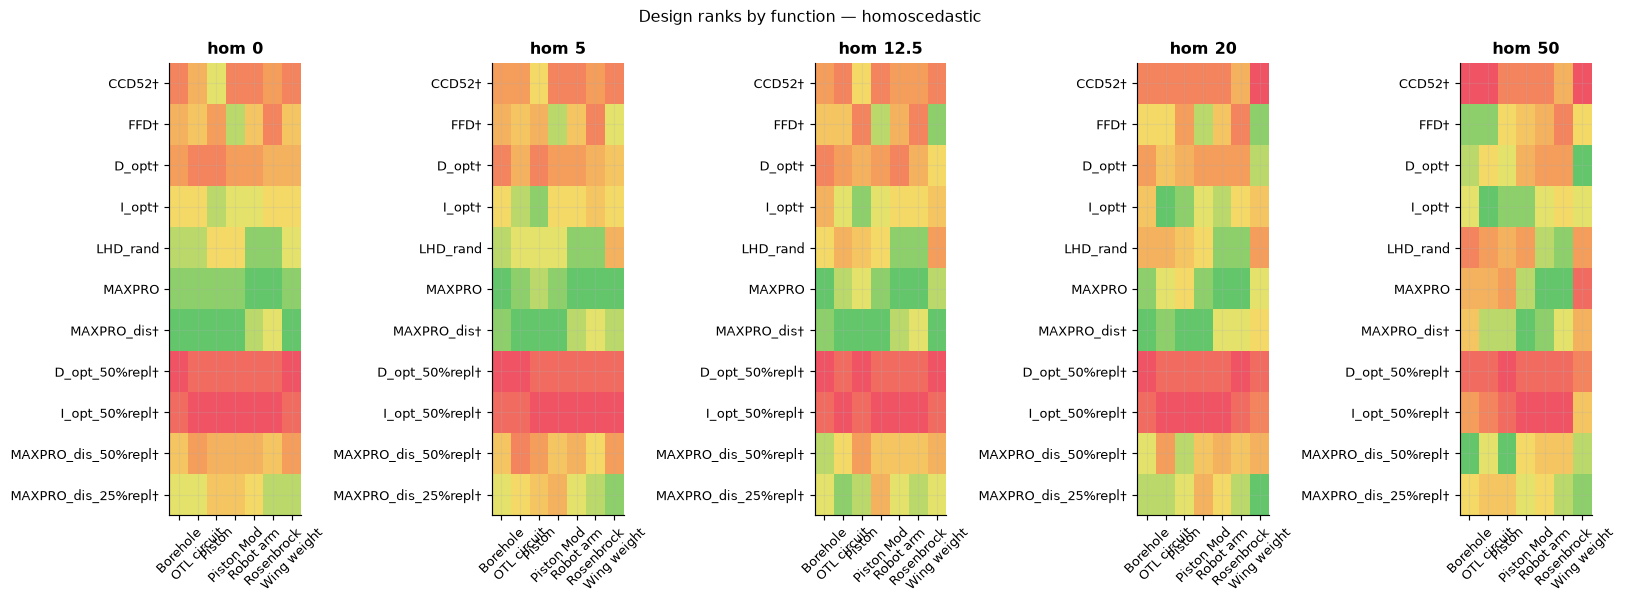

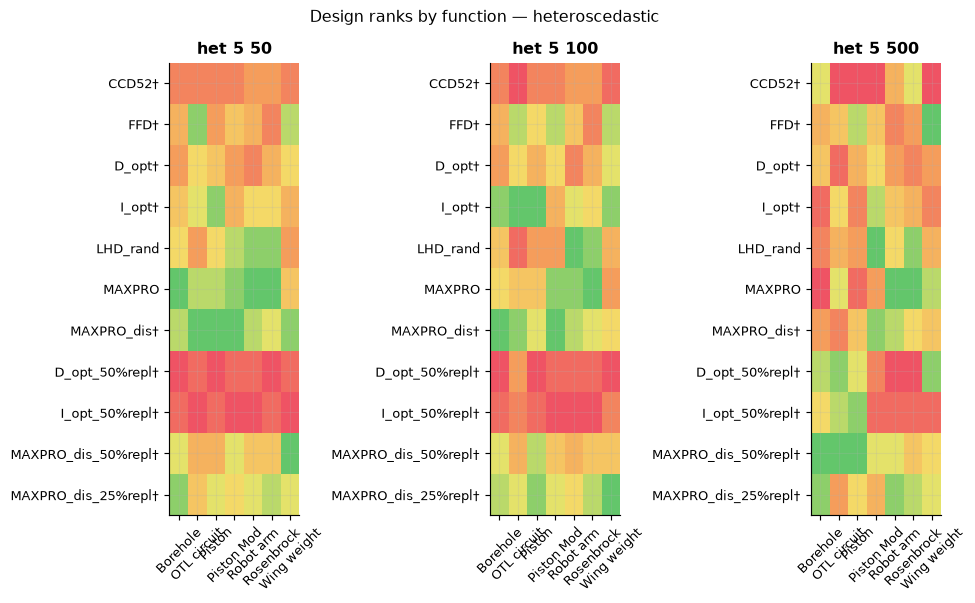

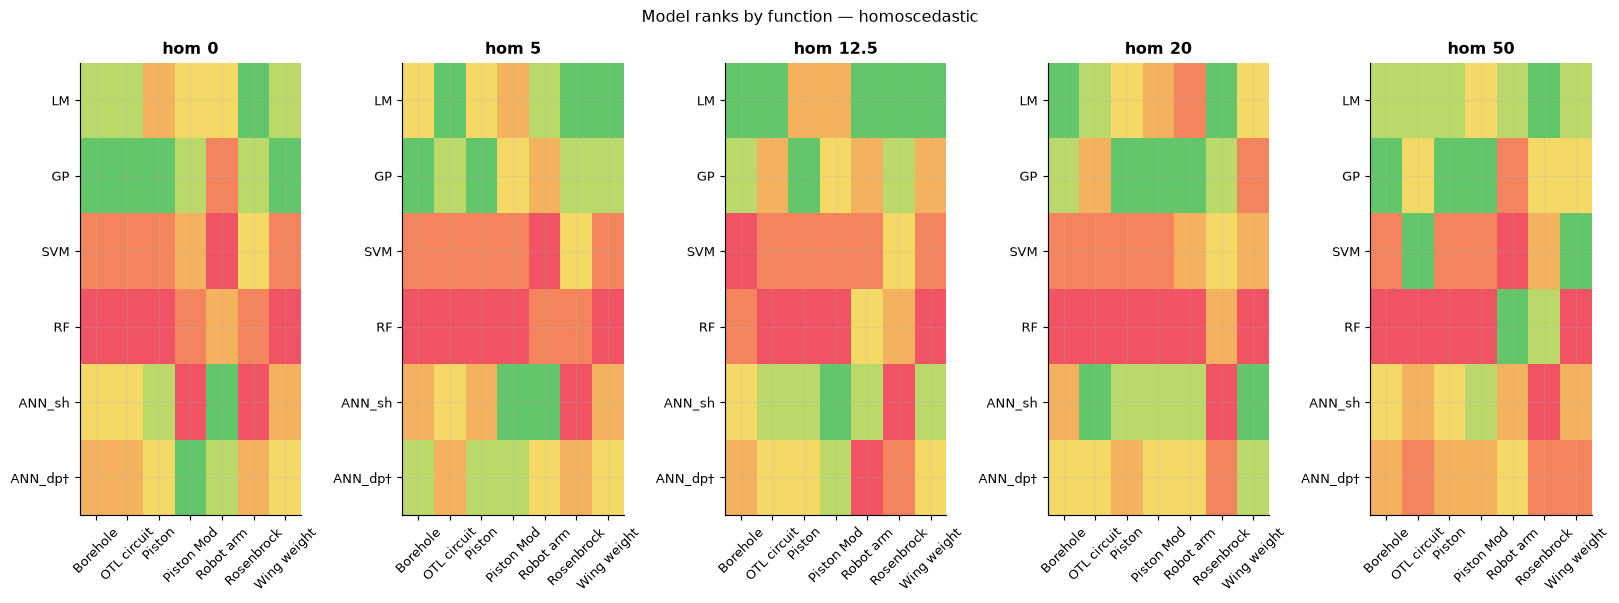

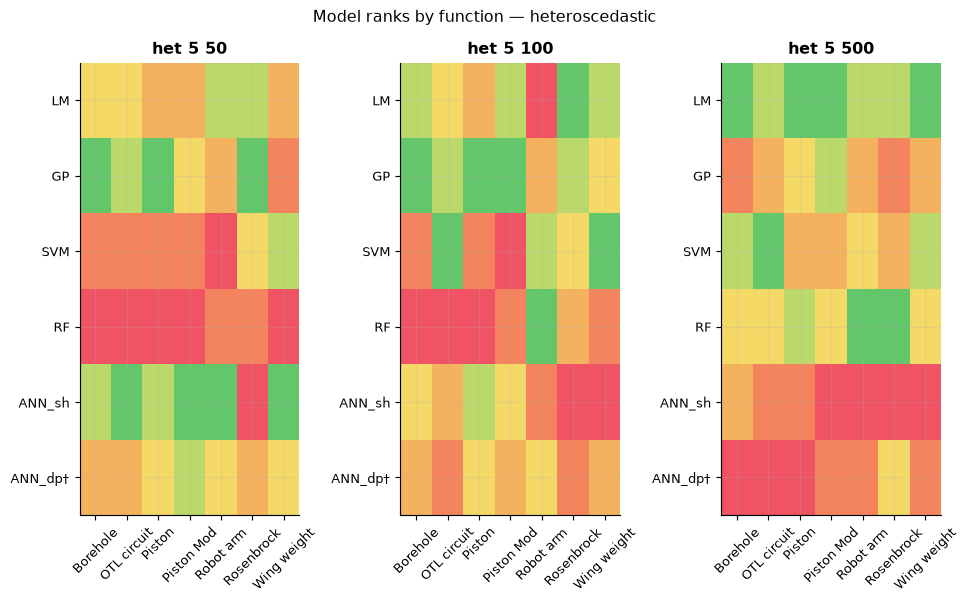

In [15]:
def heatmap(ax, table, title, vmax=None, annotate=True):
    values = table.to_numpy(float)
    vmax = vmax or np.nanmax(values)
    image = ax.imshow(values, cmap=PAPER_CMAP, vmin=1, vmax=vmax, aspect="auto")
    ax.set(
        title=title,
        xticks=np.arange(table.shape[1]),
        xticklabels=table.columns,
        yticks=np.arange(table.shape[0]),
        yticklabels=table.index,
    )
    ax.tick_params(axis="x", rotation=45)
    if annotate:
        for i in range(table.shape[0]):
            for j in range(table.shape[1]):
                ax.text(j, i, f"{values[i,j]:.0f}", ha="center", va="center", fontsize=7)
    return image

hom_labels = [n["label"] for n in NOISES if n["type"] == "homoscedastic"]
het_labels = [n["label"] for n in NOISES if n["type"] == "heteroscedastic"]

for ranks, title_prefix, item_order in [
    (design_first_ranks, "Design ranks", PRIMARY_DESIGNS),
    (model_first_ranks, "Model ranks", MODEL_NAMES),
]:
    for labels, suffix in [(hom_labels, "homoscedastic"), (het_labels, "heteroscedastic")]:
        fig, axes = plt.subplots(1, len(labels), figsize=(3.1*len(labels), 5.8), squeeze=False)
        for ax, label in zip(axes.flat, labels):
            table = (
                ranks[ranks["noise_level"] == label]
                .pivot(index="item", columns="function", values="rank")
                .reindex(item_order)
            )
            heatmap(ax, table, label.replace("_", " "), vmax=len(item_order), annotate=False)
        fig.suptitle(f"{title_prefix} by function — {suffix}")
        fig.tight_layout()
        plt.show()

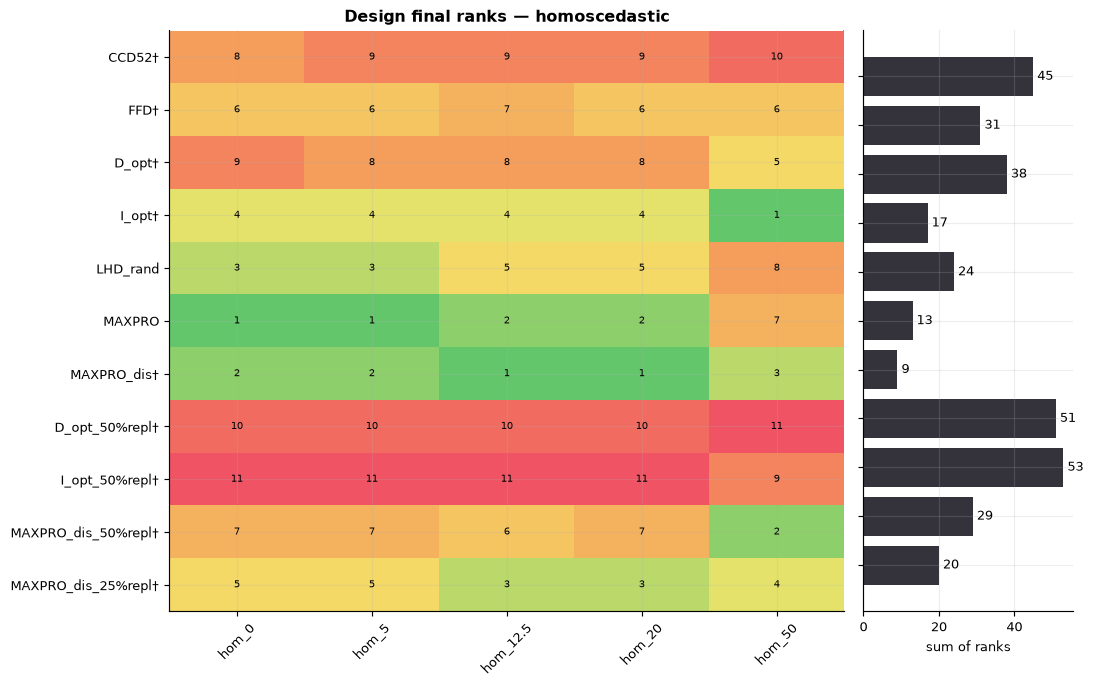

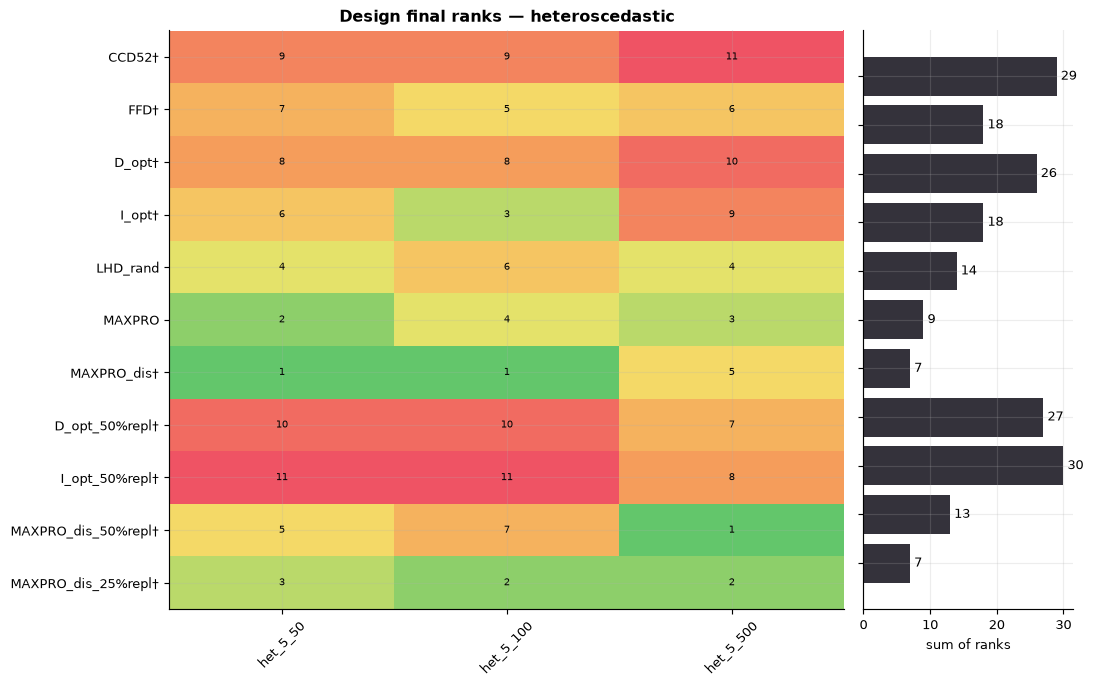

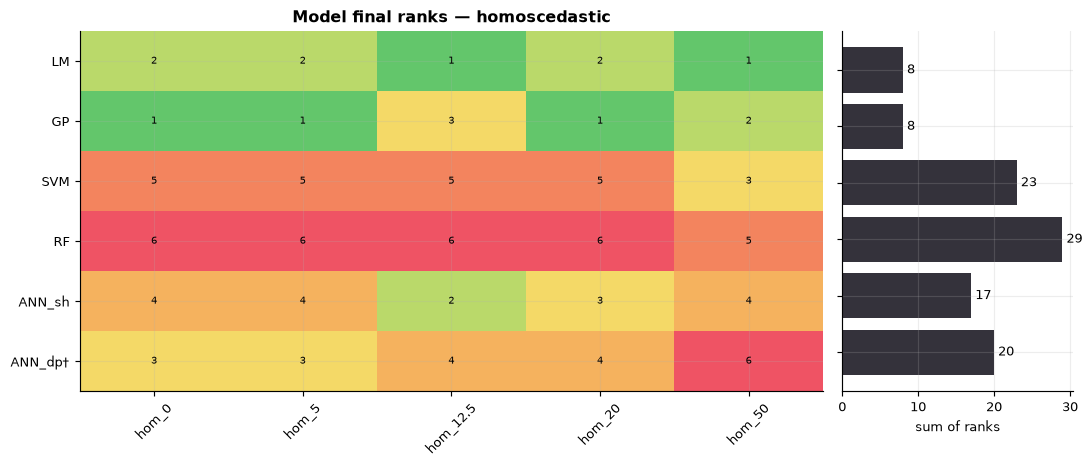

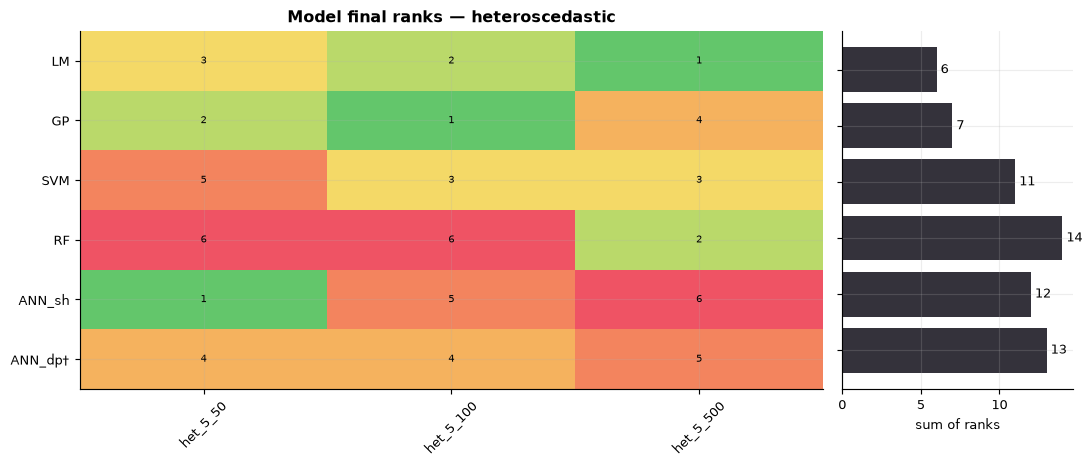

In [16]:
def rank_summary_plot(table, title):
    totals = table.sum(axis=1)
    fig, (ax, bar_ax) = plt.subplots(
        1, 2, figsize=(10.5, 0.42*len(table)+2),
        gridspec_kw={"width_ratios": [4.5, 1.4]}
    )
    heatmap(ax, table, title, vmax=len(table), annotate=True)
    y = np.arange(len(table))
    bar_ax.barh(y, totals.to_numpy(), color="#34323b")
    bar_ax.set(yticks=y, yticklabels=[], xlabel="sum of ranks")
    bar_ax.invert_yaxis()
    for yi, value in zip(y, totals):
        bar_ax.text(value, yi, f" {int(value)}", va="center")
    fig.tight_layout()
    plt.show()

rank_summary_plot(design_final[hom_labels], "Design final ranks — homoscedastic")
rank_summary_plot(design_final[het_labels], "Design final ranks — heteroscedastic")
rank_summary_plot(model_final[hom_labels], "Model final ranks — homoscedastic")
rank_summary_plot(model_final[het_labels], "Model final ranks — heteroscedastic")

## 6. Validate against the paper

### 6.1 Equal-budget sensitivity and evidence for the paper's claims

The following comparison separates the primary 52-run designs from
`BBD64†`. Claim assessments are directional rather than claims of exact
numerical replication. “Confirmed” requires the predicted ordering,
“partially reproduced” means mixed evidence, and “not reproduced” means
the observed direction opposes the paper.

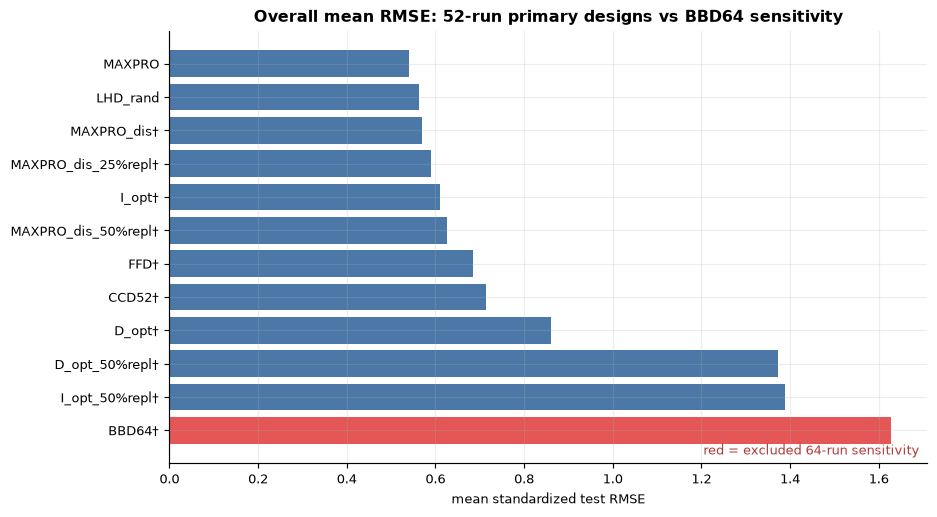

,paper_claim,assessment,evidence
0,Continuous MaxPro outperforms random LHD,confirmed,"mean RMSE: MAXPRO=0.540, LHD=0.563"
1,Discrete MaxPro outperforms six-level optimal ...,confirmed,"MAXPRO_dis†=0.569; FFD†=0.684, D_opt†=0.860, I..."
2,I-optimal outperforms D-optimal,confirmed,"I_opt†=0.611, D_opt†=0.860"
3,Replication helps mainly under severe noise,confirmed,moderate base/best repl=0.457/0.481; severe=0....
4,GP is the leading homoscedastic model,partially reproduced,GP aggregate position=2/6
5,SVM or RF overtakes GP under severe heterosced...,confirmed,"GP=1.262, SVM=1.128, RF=1.115"


In [17]:
aggregate_design = (
    ok_results.groupby("design")["rmse"].mean().sort_values()
)
colors = ["#4c78a8" if name in PRIMARY_DESIGNS else "#e45756"
          for name in aggregate_design.index]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(aggregate_design.index, aggregate_design.values, color=colors)
ax.invert_yaxis()
ax.set(
    title="Overall mean RMSE: 52-run primary designs vs BBD64 sensitivity",
    xlabel="mean standardized test RMSE",
)
ax.text(
    0.99, 0.02, "red = excluded 64-run sensitivity",
    transform=ax.transAxes, ha="right", color="#b33a3a"
)
fig.tight_layout()
plt.show()

def matched_mean(design=None, model=None, noise_levels=None):
    frame = ok_results
    if design is not None:
        frame = frame[frame["design"] == design]
    if model is not None:
        frame = frame[frame["model"] == model]
    if noise_levels is not None:
        frame = frame[frame["noise_level"].isin(noise_levels)]
    return frame["rmse"].mean()

evidence = []
def add_claim(claim, observed, expected):
    evidence.append({"paper_claim": claim, "assessment": observed, "evidence": expected})

maxpro = matched_mean(design="MAXPRO")
lhd_mean = matched_mean(design="LHD_rand")
add_claim(
    "Continuous MaxPro outperforms random LHD",
    "confirmed" if maxpro < lhd_mean else "not reproduced",
    f"mean RMSE: MAXPRO={maxpro:.3f}, LHD={lhd_mean:.3f}",
)

discrete = matched_mean(design="MAXPRO_dis†")
competitors = {d: matched_mean(design=d) for d in ["FFD†", "D_opt†", "I_opt†"]}
n_better = sum(discrete < value for value in competitors.values())
add_claim(
    "Discrete MaxPro outperforms six-level optimal competitors",
    "confirmed" if n_better == 3 else ("partially reproduced" if n_better else "not reproduced"),
    f"MAXPRO_dis†={discrete:.3f}; " + ", ".join(f"{k}={v:.3f}" for k, v in competitors.items()),
)

i_mean, d_mean = matched_mean(design="I_opt†"), matched_mean(design="D_opt†")
add_claim(
    "I-optimal outperforms D-optimal",
    "confirmed" if i_mean < d_mean else "not reproduced",
    f"I_opt†={i_mean:.3f}, D_opt†={d_mean:.3f}",
)

moderate = ["hom_12.5", "hom_20", "het_5_50", "het_5_100"]
severe = ["hom_50", "het_5_500"]
base_mod = matched_mean(design="MAXPRO_dis†", noise_levels=moderate)
repl_mod = min(
    matched_mean(design="MAXPRO_dis_25%repl†", noise_levels=moderate),
    matched_mean(design="MAXPRO_dis_50%repl†", noise_levels=moderate),
)
base_sev = matched_mean(design="MAXPRO_dis†", noise_levels=severe)
repl_sev = min(
    matched_mean(design="MAXPRO_dis_25%repl†", noise_levels=severe),
    matched_mean(design="MAXPRO_dis_50%repl†", noise_levels=severe),
)
replication_status = (
    "confirmed" if repl_mod >= base_mod and repl_sev < base_sev
    else "partially reproduced" if repl_sev < base_sev else "not reproduced"
)
add_claim(
    "Replication helps mainly under severe noise",
    replication_status,
    f"moderate base/best repl={base_mod:.3f}/{repl_mod:.3f}; "
    f"severe={base_sev:.3f}/{repl_sev:.3f}",
)

hom_model_means = (
    ok_results[ok_results["noise_level"].isin(hom_labels)]
    .groupby("model")["rmse"].mean().sort_values()
)
gp_rank = hom_model_means.index.get_loc("GP") + 1
add_claim(
    "GP is the leading homoscedastic model",
    "confirmed" if gp_rank == 1 else ("partially reproduced" if gp_rank <= 3 else "not reproduced"),
    f"GP aggregate position={gp_rank}/{len(hom_model_means)}",
)

severe_models = (
    ok_results[ok_results["noise_level"] == "het_5_500"]
    .groupby("model")["rmse"].mean()
)
best_robust = min(severe_models["SVM"], severe_models["RF"])
add_claim(
    "SVM or RF overtakes GP under severe heteroscedasticity",
    "confirmed" if best_robust < severe_models["GP"] else "not reproduced",
    f"GP={severe_models['GP']:.3f}, SVM={severe_models['SVM']:.3f}, RF={severe_models['RF']:.3f}",
)

evidence_df = pd.DataFrame(evidence)
evidence_df

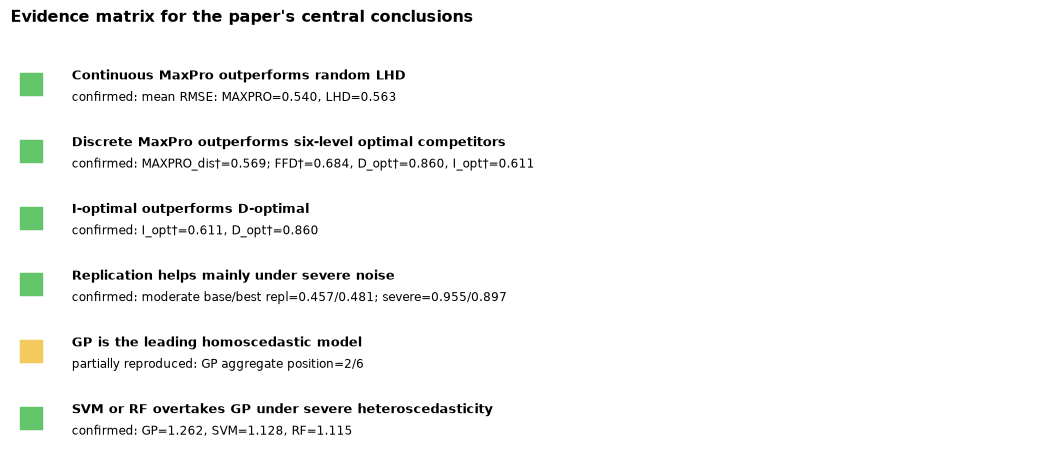

In [18]:
assessment_colors = {
    "confirmed": "#63c66b",
    "partially reproduced": "#f4c95d",
    "not reproduced": "#ef6a6a",
}
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.axis("off")
y_positions = np.arange(len(evidence_df))[::-1]
for y, row in zip(y_positions, evidence_df.itertuples()):
    ax.scatter(
        0.02, y, s=220, marker="s",
        color=assessment_colors[row.assessment], transform=ax.transData
    )
    ax.text(0.06, y+0.12, row.paper_claim, weight="bold", va="center")
    ax.text(0.06, y-0.20, f"{row.assessment}: {row.evidence}", va="center", fontsize=8)
ax.set(xlim=(0, 1), ylim=(-0.7, len(evidence_df)-0.2))
ax.set_title("Evidence matrix for the paper's central conclusions", loc="left")
fig.tight_layout()
plt.show()

## 7. Go beyond the paper

The notebook's open-source substitutions are themselves the teaching extension. It enforces an equal 52-run primary budget, isolates the 64-run BBD as a sensitivity case, exposes every approximated design with `†`, and reports where those approximations do or do not preserve the paper's directional conclusions. This demonstrates why design rankings are conditional on implementation, run budget, response shape, noise, and predictive model—not universal properties of a design name.

## 8. Practitioner conclusions

This notebook reproduces the full structure of the study—functions,
noise, small experimental designs, predictive models, repeated test
RMSE, and two-stage ranks—using a constrained open-source stack.
The evidence matrix above is the result, not a guarantee: approximate
design generators can change rankings, especially the generalized
discrete MaxPro result.

Key interpretation rules:

1. Treat comparisons among the 52-run designs as the primary evidence.
2. Treat `BBD64†` only as a sensitivity analysis because it receives
   23% more runs.
3. Treat `MAXPRO_dis†` as evidence about *balanced six-level projection
   of a MaxPro design*, not as validation of Joseph et al.'s generalized
   discrete MaxPro criterion.
4. Treat model results as predictive-RMSE comparisons only. They do not
   assess uncertainty calibration, interpretability, or causality.
5. Switch `PROFILE` to `"paper_scale"` and re-run for the publication
   budgets. Expect a substantially longer computation.

## 9. Reproducibility metadata

The setup cell prints the full active profile, PyDOE source path, and library versions used by the saved run. This saved execution used Python 3.12 with `pydoe` from the adjacent development checkout, NumPy 2.5.1, pandas 3.0.5, SciPy 1.18.0, scikit-learn 1.9.0, and Matplotlib 3.11.1. The fixed base seed is `20220725`; derived seeds use a stable CRC32 mapping of the simulation coordinates. The collection-wide [`requirements.txt`](requirements.txt) is the supported common rerun environment.